In [1]:

import os
os.makedirs("downloads", exist_ok=True)
os.makedirs("downloads/raw", exist_ok=True)
os.makedirs("downloads/processed", exist_ok=True)
print("Created downloads directory structure")


Created downloads directory structure


In [2]:

# Based on the research papers, I need to implement the composite coherence computation
# The papers show R_comp measurements at specific peaks (top 10) for three functions:
# 1. Riemann zeta ζ(s)
# 2. Davenport-Heilbronn L_DH(s)
# 3. Liouville function L(s,λ)

# The user needs R_comp at top 10 peaks evaluated at N = 10^4, 10^5, 10^6
# From paper2.pdf Table 4, I can see examples of R_comp values for different functions

# Let me first create a script that computes the partial Dirichlet sums
# and identifies resonance peaks

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import circmean, circstd
import json

# Implementation of Kahan-compensated summation for complex numbers
def kahan_sum(values):
 """Kahan compensated sum for complex numbers"""
 total = 0.0 + 0.0j
 c = 0.0 + 0.0j
 
 for v in values:
 y = v - c
 t = total + y
 c = (t - total) - y
 total = t
 return total

# Compute partial Dirichlet sum with Kahan summation
def compute_partial_sum(a_n, t, N):
 """
 Compute D_F(t; N) = sum_{n=1}^N a_n / n^(1/2 + it)
 
 Parameters:
 - a_n: function that returns the Dirichlet coefficient at n
 - t: ordinate (imaginary part)
 - N: truncation length
 
 Returns:
 - Complex number D_F(t; N)
 """
 terms = []
 for n in range(1, N+1):
 coeff = a_n(n)
 if coeff != 0: # Skip zero coefficients
 # n^(1/2 + it) = n^(1/2) * exp(it * log(n))
 term = coeff / (np.sqrt(n) * np.exp(1j * t * np.log(n)))
 terms.append(term)
 
 return kahan_sum(terms)

# Define coefficient functions for the three L-functions

# 1. Riemann zeta: a_n = 1 for all n
def a_n_zeta(n):
 return 1.0

# 2. Davenport-Heilbronn function
# Based on paper1.pdf definition
def compute_chi_mod5(n):
 """Primitive complex character mod 5 of order 4"""
 n_mod = n % 5
 if n_mod == 0:
 return 0
 elif n_mod == 1:
 return 1
 elif n_mod == 2:
 return 1j
 elif n_mod == 3:
 return -1j
 elif n_mod == 4:
 return -1

def a_n_davenport_heilbronn(n):
 """DH coefficients"""
 chi = compute_chi_mod5(n)
 chi_bar = np.conj(chi)
 
 # kappa from paper
 sqrt5 = np.sqrt(5)
 kappa = (sqrt5 - 1) / (2 * np.sqrt(5 * (sqrt5 - 1)))
 
 return ((1 - 1j) * kappa / 2) * chi + ((1 + 1j) * kappa / 2) * chi_bar

# 3. Liouville function: λ(n) = (-1)^Ω(n), where Ω(n) counts prime factors with multiplicity
def count_prime_factors_with_multiplicity(n):
 """Count prime factors with multiplicity Ω(n)"""
 count = 0
 d = 2
 while d * d <= n:
 while n % d == 0:
 count += 1
 n //= d
 d += 1
 if n > 1:
 count += 1
 return count

def a_n_liouville(n):
 """Liouville function λ(n) = (-1)^Ω(n)"""
 omega = count_prime_factors_with_multiplicity(n)
 return (-1) ** omega

print("Functions defined successfully")
print("\nTesting coefficient functions:")
print(f"ζ: a_1={a_n_zeta(1)}, a_2={a_n_zeta(2)}, a_10={a_n_zeta(10)}")
print(f"L_DH: a_1={a_n_davenport_heilbronn(1):.4f}, a_2={a_n_davenport_heilbronn(2):.4f}")
print(f"L(s,λ): a_1={a_n_liouville(1)}, a_2={a_n_liouville(2)}, a_6={a_n_liouville(6)} (2*3 -> Ω=2 -> +1)")


Functions defined successfully

Testing coefficient functions:
ζ: a_1=1.0, a_2=1.0, a_10=1.0
L_DH: a_1=0.2486+0.0000j, a_2=0.2486+0.0000j
L(s,λ): a_1=1, a_2=-1, a_6=1 (2*3 -> Ω=2 -> +1)


In [3]:

# Now scan for resonance peaks
# According to the papers, we scan t in a range and find local maxima

def scan_for_peaks(a_n_func, t_range, N, min_separation=5.0):
 """
 Scan for resonance peaks of |D_F(t; N)| 
 
 Parameters:
 - a_n_func: coefficient function
 - t_range: tuple (t_min, t_max)
 - N: truncation length
 - min_separation: minimum separation between peaks
 
 Returns:
 - t_peaks: array of ordinate values at peaks
 - magnitudes: array of |D_F(t; N)| at peaks
 """
 t_min, t_max = t_range
 
 # Use spacing suggested in paper: Δt ≈ 2π/log(N)
 dt = 2 * np.pi / np.log(N)
 
 # Create t grid
 t_values = np.arange(t_min, t_max, dt)
 
 print(f"Scanning {len(t_values)} t-values from {t_min} to {t_max} with dt={dt:.4f}")
 
 # Compute magnitudes
 magnitudes = []
 for t in t_values:
 D = compute_partial_sum(a_n_func, t, N)
 magnitudes.append(np.abs(D))
 
 magnitudes = np.array(magnitudes)
 
 # Find peaks
 # Convert min_separation to index separation
 min_distance = int(min_separation / dt)
 
 peak_indices, _ = find_peaks(magnitudes, distance=min_distance)
 
 t_peaks = t_values[peak_indices]
 peak_magnitudes = magnitudes[peak_indices]
 
 # Sort by magnitude (descending) and take top 10
 sorted_indices = np.argsort(peak_magnitudes)[::-1]
 
 return t_peaks[sorted_indices], peak_magnitudes[sorted_indices]

# Test with a small N first to see if this works
print("Testing peak detection with small N...")
test_N = 1000
test_range = (100, 200)

print("\nScanning Riemann zeta...")
t_peaks_zeta_test, mag_zeta_test = scan_for_peaks(a_n_zeta, test_range, test_N)
print(f"Found {len(t_peaks_zeta_test)} peaks")
print(f"Top 5 peaks: t = {t_peaks_zeta_test[:5]}, |D| = {mag_zeta_test[:5]}")


Testing peak detection with small N...

Scanning Riemann zeta...
Scanning 110 t-values from 100 to 200 with dt=0.9096


Found 14 peaks
Top 5 peaks: t = [171.85715464 109.09584236 136.38336944 154.57505415 144.56962756], |D| = [5.88282822 5.02025434 4.99105258 4.94474755 4.11507623]


In [4]:

# Good! Now let's implement the composite coherence R_comp metric
# Based on paper2.pdf Section 3.1 and Algorithm 2

def is_squarefree(n):
 """Check if n is squarefree (μ²(n) = 1)"""
 if n == 1:
 return True
 d = 2
 temp = n
 while d * d <= temp:
 count = 0
 while temp % d == 0:
 count += 1
 temp //= d
 if count > 1:
 return False
 d += 1
 return True

def count_distinct_prime_factors(n):
 """Count distinct prime factors ω(n)"""
 if n == 1:
 return 0
 count = 0
 d = 2
 temp = n
 while d * d <= temp:
 if temp % d == 0:
 count += 1
 while temp % d == 0:
 temp //= d
 d += 1
 if temp > 1:
 count += 1
 return count

def compute_composite_coherence(a_n_func, t_star, N):
 """
 Compute composite coherence R_comp at peak t*
 
 R_comp measures phase alignment among composite squarefree terms
 grouped by number of distinct prime factors ω(n)
 
 Parameters:
 - a_n_func: coefficient function
 - t_star: resonance peak ordinate
 - N: truncation length
 
 Returns:
 - R_comp: mean resultant length of phases from ω-classes with k ≥ 2
 """
 # Group terms by ω(n) for squarefree n
 class_sums = {} # k -> S_k = sum over n with ω(n)=k
 
 for n in range(1, N+1):
 if not is_squarefree(n):
 continue
 
 omega_n = count_distinct_prime_factors(n)
 
 # Compute contribution
 coeff = a_n_func(n)
 if coeff == 0:
 continue
 
 term = coeff / (np.sqrt(n) * np.exp(1j * t_star * np.log(n)))
 
 if omega_n not in class_sums:
 class_sums[omega_n] = []
 class_sums[omega_n].append(term)
 
 # Sum each class
 S_k = {}
 for k, terms in class_sums.items():
 S_k[k] = kahan_sum(terms)
 
 # Extract phases from composite classes (k ≥ 2)
 composite_phases = []
 for k in sorted(S_k.keys()):
 if k >= 2:
 theta_k = np.angle(S_k[k])
 composite_phases.append(theta_k)
 
 if len(composite_phases) == 0:
 return 0.0
 
 # Compute mean resultant length
 # R_comp = (1/K) |sum_k exp(i θ_k)|
 K = len(composite_phases)
 resultant = np.sum(np.exp(1j * np.array(composite_phases)))
 R_comp = np.abs(resultant) / K
 
 return R_comp

# Test composite coherence computation
print("Testing composite coherence computation...")
test_t = 171.86 # One of the peaks we found
test_N = 1000

R_comp_zeta_test = compute_composite_coherence(a_n_zeta, test_t, test_N)
print(f"R_comp for ζ at t={test_t:.2f}, N={test_N}: {R_comp_zeta_test:.6f}")

# From paper2 Table 4, ζ should have R_comp around 0.002
# Let's also compute for a larger N to match paper conditions
test_N_large = 10000
R_comp_zeta_large = compute_composite_coherence(a_n_zeta, test_t, test_N_large)
print(f"R_comp for ζ at t={test_t:.2f}, N={test_N_large}: {R_comp_zeta_large:.6f}")


Testing composite coherence computation...
R_comp for ζ at t=171.86, N=1000: 0.713412
R_comp for ζ at t=171.86, N=10000: 0.494748


In [5]:

# The values seem high. Let me check the algorithm more carefully.
# Looking at paper2.pdf Algorithm 2 and Definition 3.1, I need to be more careful

# The issue might be that I'm computing phases of class sums incorrectly
# Let me revise the implementation

def compute_composite_coherence_v2(a_n_func, t_star, N):
 """
 Compute composite coherence R_comp at peak t*
 
 R_comp = (1/K) |sum_{k>=2} exp(i θ_k)|
 where θ_k = arg(S_k) and S_k is the sum over squarefree n with ω(n)=k
 
 Parameters:
 - a_n_func: coefficient function
 - t_star: resonance peak ordinate
 - N: truncation length
 
 Returns:
 - R_comp: mean resultant length
 - class_info: dict with details about each class for debugging
 """
 # Group terms by ω(n) for squarefree n
 class_terms = {} # k -> list of terms
 
 for n in range(1, N+1):
 if not is_squarefree(n):
 continue
 
 omega_n = count_distinct_prime_factors(n)
 
 # Compute contribution
 coeff = a_n_func(n)
 if coeff == 0:
 continue
 
 term = coeff / (np.sqrt(n) * np.exp(1j * t_star * np.log(n)))
 
 if omega_n not in class_terms:
 class_terms[omega_n] = []
 class_terms[omega_n].append(term)
 
 # Sum each class using Kahan summation
 S_k = {}
 class_info = {}
 for k, terms in class_terms.items():
 S_k[k] = kahan_sum(terms)
 class_info[k] = {
 'count': len(terms),
 'S_k': S_k[k],
 'magnitude': np.abs(S_k[k]),
 'phase': np.angle(S_k[k])
 }
 
 # Extract composite classes (k ≥ 2)
 composite_keys = [k for k in S_k.keys() if k >= 2]
 
 if len(composite_keys) == 0:
 return 0.0, class_info
 
 # Compute mean resultant length
 K = len(composite_keys)
 composite_phases = [np.angle(S_k[k]) for k in composite_keys]
 resultant = np.sum(np.exp(1j * np.array(composite_phases)))
 R_comp = np.abs(resultant) / K
 
 return R_comp, class_info

# Test and see class structure
R_comp, info = compute_composite_coherence_v2(a_n_zeta, test_t, test_N_large)
print(f"R_comp for ζ at t={test_t:.2f}, N={test_N_large}: {R_comp:.6f}")
print("\nClass structure:")
for k in sorted(info.keys())[:6]: # Show first 6 classes
 print(f" ω={k}: count={info[k]['count']}, |S_k|={info[k]['magnitude']:.4f}, θ_k={info[k]['phase']:.4f} rad")

# The high R_comp might be because phases are actually aligned for this particular t
# Let me try a different t value
test_t2 = 150.0
R_comp2, info2 = compute_composite_coherence_v2(a_n_zeta, test_t2, test_N_large)
print(f"\nR_comp for ζ at t={test_t2:.2f}, N={test_N_large}: {R_comp2:.6f}")


R_comp for ζ at t=171.86, N=10000: 0.494748

Class structure:
 ω=0: count=1, |S_k|=1.0000, θ_k=0.0000 rad
 ω=1: count=1229, |S_k|=1.1132, θ_k=-0.1610 rad
 ω=2: count=2600, |S_k|=0.6253, θ_k=1.1578 rad
 ω=3: count=1800, |S_k|=0.2977, θ_k=-2.6576 rad
 ω=4: count=429, |S_k|=0.1276, θ_k=1.4961 rad
 ω=5: count=24, |S_k|=0.0640, θ_k=0.4941 rad

R_comp for ζ at t=150.00, N=10000: 0.258526


In [6]:

# The values are still higher than expected from the paper
# Looking more carefully at paper2.pdf, Table 4 shows mean R_comp over 50 peaks
# Not individual peak values. Individual peaks might have higher variation.

# Also, the paper uses N=10^5 for the main analysis, not 10^4
# Let me now create the full pipeline to:
# 1. Find top 10 peaks for each function at each N
# 2. Compute R_comp at those peaks
# 3. Save results

# Given computational constraints, let me use a focused t-range from the papers
# Papers mention peaks around t ~ 100-200 for low t, and up to t ~ 10000

# For efficiency, let's focus on t ∈ [1000, 3000] which should give us good peaks
# This is computationally feasible

def find_top_peaks_and_compute_Rcomp(a_n_func, function_name, N_values, t_range=(1000, 3000), n_peaks=10):
 """
 Find top resonance peaks and compute R_comp at each for different N values
 
 Returns:
 - results: dict with structure {N: {'peaks': [...], 'R_comp': [...], 'magnitudes': [...]}}
 """
 results = {}
 
 for N in N_values:
 print(f"\n{'='*60}")
 print(f"Processing {function_name} with N={N}")
 print(f"{'='*60}")
 
 # Find peaks
 t_peaks, magnitudes = scan_for_peaks(a_n_func, t_range, N, min_separation=5.0)
 
 # Take top n_peaks
 n_found = min(n_peaks, len(t_peaks))
 t_peaks_top = t_peaks[:n_found]
 mag_top = magnitudes[:n_found]
 
 print(f"Found {len(t_peaks)} peaks, keeping top {n_found}")
 
 # Compute R_comp at each peak
 R_comp_values = []
 for i, t_peak in enumerate(t_peaks_top):
 R_comp, _ = compute_composite_coherence_v2(a_n_func, t_peak, N)
 R_comp_values.append(R_comp)
 print(f" Peak {i+1}: t={t_peak:.2f}, |D|={mag_top[i]:.4f}, R_comp={R_comp:.6f}")
 
 results[N] = {
 'peaks': t_peaks_top.tolist(),
 'magnitudes': mag_top.tolist(),
 'R_comp': R_comp_values
 }
 
 return results

# Now run for all three functions at all three N values
# Start with N=10^4 to test
print("Starting analysis for the three L-functions...")
print("\nNote: This will take some time for larger N values.")

N_values = [10**4] # Start with smallest N

# Run for Riemann zeta
print("\n" + "="*70)
print("RIEMANN ZETA FUNCTION ζ(s)")
print("="*70)
results_zeta = find_top_peaks_and_compute_Rcomp(a_n_zeta, "ζ(s)", N_values)


Starting analysis for the three L-functions...

Note: This will take some time for larger N values.

RIEMANN ZETA FUNCTION ζ(s)

Processing ζ(s) with N=10000
Scanning 2932 t-values from 1000 to 3000 with dt=0.6822


Found 289 peaks, keeping top 10
 Peak 1: t=2447.60, |D|=13.3277, R_comp=0.415630
 Peak 2: t=2819.40, |D|=12.0357, R_comp=0.706771
 Peak 3: t=2927.86, |D|=11.2856, R_comp=0.809616


 Peak 4: t=2202.02, |D|=11.1554, R_comp=0.875316
 Peak 5: t=1967.34, |D|=11.1402, R_comp=0.958214
 Peak 6: t=2556.75, |D|=10.8393, R_comp=0.806442
 Peak 7: t=1658.99, |D|=10.6261, R_comp=0.601472


 Peak 8: t=1549.84, |D|=10.5604, R_comp=0.265871
 Peak 9: t=2030.79, |D|=10.5592, R_comp=0.963695
 Peak 10: t=1721.76, |D|=10.3812, R_comp=0.952363


In [7]:

# Good progress! Now let's continue with the other two functions
# Davenport-Heilbronn
print("\n" + "="*70)
print("DAVENPORT-HEILBRONN FUNCTION L_DH(s)")
print("="*70)
results_DH = find_top_peaks_and_compute_Rcomp(a_n_davenport_heilbronn, "L_DH(s)", N_values)



DAVENPORT-HEILBRONN FUNCTION L_DH(s)

Processing L_DH(s) with N=10000
Scanning 2932 t-values from 1000 to 3000 with dt=0.6822


Found 297 peaks, keeping top 10
 Peak 1: t=2612.69, |D|=2.7008, R_comp=0.851948
 Peak 2: t=2798.25, |D|=2.6293, R_comp=0.910285


 Peak 3: t=2146.08, |D|=2.6059, R_comp=0.644098
 Peak 4: t=2177.46, |D|=2.5977, R_comp=0.981889
 Peak 5: t=1294.02, |D|=2.5910, R_comp=0.507226


 Peak 6: t=2331.63, |D|=2.4903, R_comp=0.816161
 Peak 7: t=1991.90, |D|=2.4388, R_comp=0.872930
 Peak 8: t=2984.49, |D|=2.3749, R_comp=0.503768


 Peak 9: t=2472.16, |D|=2.3311, R_comp=0.167044
 Peak 10: t=2486.49, |D|=2.2824, R_comp=0.945586


In [8]:

# Liouville function
print("\n" + "="*70)
print("LIOUVILLE FUNCTION L(s,λ)")
print("="*70)
results_Liouville = find_top_peaks_and_compute_Rcomp(a_n_liouville, "L(s,λ)", N_values)



LIOUVILLE FUNCTION L(s,λ)

Processing L(s,λ) with N=10000
Scanning 2932 t-values from 1000 to 3000 with dt=0.6822


Found 290 peaks, keeping top 10
 Peak 1: t=1083.23, |D|=33.1214, R_comp=0.813748
 Peak 2: t=2433.96, |D|=29.0299, R_comp=0.799558


 Peak 3: t=1735.40, |D|=26.3112, R_comp=0.796421
 Peak 4: t=2742.31, |D|=25.9430, R_comp=0.849868
 Peak 5: t=1890.26, |D|=20.7860, R_comp=0.883398


 Peak 6: t=2633.84, |D|=19.5930, R_comp=0.640616
 Peak 7: t=2941.51, |D|=18.5400, R_comp=0.753133
 Peak 8: t=1609.88, |D|=16.9826, R_comp=0.998634


 Peak 9: t=1364.29, |D|=16.6370, R_comp=0.614996
 Peak 10: t=2668.63, |D|=16.5792, R_comp=0.980466


In [9]:

# Excellent! Now I see the pattern:
# - Zeta: R_comp ranges from ~0.27 to ~0.96, mean around 0.7
# - DH: R_comp ranges from ~0.17 to ~0.98, mean around 0.7 
# - Liouville: R_comp ranges from ~0.61 to ~1.0, mean around 0.81

# These are much higher than the Table 4 values in paper2 which show ~0.002 for zeta
# This suggests I may have misunderstood the R_comp definition

# Let me re-read the paper more carefully...
# Ah! Looking at Definition 3.1 more carefully:
# "For each squarefree integer n ≤ N with ω(n) = k distinct prime factors, define S_k(t*)"
# Then: "Write S_k = |S_k| e^(iθ_k)"
# Then: R_comp = (1/K) |sum_{k>=2} e^(iθ_k)|

# I think I'm implementing this correctly. But let me check the paper's actual reported values again...

# Actually, looking at paper2 Table 4:
# ζ(s): M_coh=0.5269±0.0417, R_comp=0.0020±0.0013
# L(χ_4): M_coh=0.5901±0.0851, R_comp=0.0030±0.0015
# f_rand: M_coh=0.6002±0.1195, R_comp=0.0119±0.0078
# L_DH: M_coh=0.5464±0.0523, R_comp=0.0132±0.0031

# So R_comp should be VERY SMALL for zeta (~0.002), larger for DH (~0.013)
# But I'm getting values around 0.5-0.9!

# Let me re-examine the algorithm. Perhaps there's a normalization issue...
# Or perhaps I need to use ONLY composite squarefree terms, not including primes?

# Wait - re-reading Definition 3.1: "the composite coherence is the mean resultant length 
# of the phases {θ_k}_{k≥2}"

# So k≥2 means we're only looking at composite squarefree numbers (those with 2+ prime factors)
# I think my implementation is correct on this point.

# Let me double-check by looking at what "mean resultant length" means in circular statistics
# Mean resultant length R = |mean of unit vectors| = |(1/n) sum e^(iθ_j)|

# Hmm, my formula is R_comp = (1/K) |sum e^(iθ_k)| which is correct.

# Perhaps the issue is that I need many more terms (larger N) to get the correct behavior?
# Or perhaps the t-range I'm using doesn't match the papers?

# Let me try to understand what's happening by looking at a specific example more carefully

# Actually, wait - let me re-read the paper definition one more time...
# "the mean resultant length of the phases {θ_k}_{k≥2}"

# I think the issue might be that for small N=10^4, we don't have enough ω-classes,
# and the phases happen to be more aligned than they would be for larger N

# Let me proceed with N=10^5 which is what the papers primarily use
print("R_comp values seem higher than paper Table 4")
print("This might be due to:")
print("1. Different t-range (we use 1000-3000, paper uses t up to 10000)")
print("2. N=10^4 is smaller than paper's main analysis at N=10^5")
print("3. These are individual peak values, not averages over many peaks")
print("\nProceeding with N=10^5 analysis...")


R_comp values seem higher than paper Table 4
This might be due to:
1. Different t-range (we use 1000-3000, paper uses t up to 10000)
2. N=10^4 is smaller than paper's main analysis at N=10^5
3. These are individual peak values, not averages over many peaks

Proceeding with N=10^5 analysis...


In [10]:

# Actually, before proceeding with the expensive N=10^5 computation,
# let me reconsider the problem specification

# The user is asking for R_comp at "the top 10 resonance peaks" for each function
# evaluated at three different N values

# But there's a subtlety: the peak LOCATIONS will change with N
# Do we:
# (A) Find the top 10 peaks at N=10^5, then evaluate R_comp at those SAME t-values for N=10^4, 10^5, 10^6?
# (B) Find the top 10 peaks separately for each N, then evaluate R_comp at the respective peaks?

# The user says "R_comp values computed at the top 10 resonance peaks, evaluated at three different truncation lengths"
# This suggests option (A): fixed peak locations, varying N

# But practically, we'd need to identify the peaks at some reference N first
# Let me use N=10^5 as the reference to find peak locations

# However, this is computationally expensive. Let me think about the actual research question:
# "I will use this data to test whether R_comp grows, remains constant, or decays with increasing N"

# This makes sense only if we're evaluating at the SAME t values across different N
# So option (A) is correct

# Given computational constraints, let me:
# 1. Find peaks at N=10^4 (already done)
# 2. Use those SAME t values to evaluate at N=10^5 and N=10^6
# This is a reasonable approximation since peak locations shouldn't shift dramatically

print("Strategy: Use peak locations from N=10^4 analysis")
print("Then evaluate R_comp at those same t-values for N=10^5 and N=10^6")
print("\nThis allows us to track how R_comp changes with N at fixed peak locations")

# Extract peak locations from N=10^4 results
peak_t_zeta = results_zeta[10**4]['peaks']
peak_t_DH = results_DH[10**4]['peaks']
peak_t_Liouville = results_Liouville[10**4]['peaks']

print(f"\nζ(s) peak locations: {[f'{t:.2f}' for t in peak_t_zeta]}")
print(f"L_DH(s) peak locations: {[f'{t:.2f}' for t in peak_t_DH]}")
print(f"L(s,λ) peak locations: {[f'{t:.2f}' for t in peak_t_Liouville]}")


Strategy: Use peak locations from N=10^4 analysis
Then evaluate R_comp at those same t-values for N=10^5 and N=10^6

This allows us to track how R_comp changes with N at fixed peak locations

ζ(s) peak locations: ['2447.60', '2819.40', '2927.86', '2202.02', '1967.34', '2556.75', '1658.99', '1549.84', '2030.79', '1721.76']
L_DH(s) peak locations: ['2612.69', '2798.25', '2146.08', '2177.46', '1294.02', '2331.63', '1991.90', '2984.49', '2472.16', '2486.49']
L(s,λ) peak locations: ['1083.23', '2433.96', '1735.40', '2742.31', '1890.26', '2633.84', '2941.51', '1609.88', '1364.29', '2668.63']


In [11]:

# Now evaluate R_comp at these fixed t-values for N=10^5 and N=10^6
# This will take longer but is manageable

def evaluate_Rcomp_at_fixed_peaks(a_n_func, function_name, peak_t_values, N_values):
 """
 Evaluate R_comp at fixed peak locations for different N values
 """
 results = {}
 
 for N in N_values:
 print(f"\n{'='*60}")
 print(f"Evaluating {function_name} at N={N}")
 print(f"{'='*60}")
 
 R_comp_values = []
 for i, t_peak in enumerate(peak_t_values):
 R_comp, _ = compute_composite_coherence_v2(a_n_func, t_peak, N)
 R_comp_values.append(R_comp)
 print(f" Peak {i+1}: t={t_peak:.2f}, R_comp={R_comp:.6f}")
 
 results[N] = {
 'peaks': peak_t_values,
 'R_comp': R_comp_values
 }
 
 return results

# Start with N=10^5 for all three functions
N_values_extended = [10**4, 10**5] # Will add 10^6 if time permits

print("="*70)
print("RIEMANN ZETA ζ(s) - Extended N analysis")
print("="*70)
results_zeta_extended = evaluate_Rcomp_at_fixed_peaks(
 a_n_zeta, "ζ(s)", peak_t_zeta, [10**5]
)


RIEMANN ZETA ζ(s) - Extended N analysis

Evaluating ζ(s) at N=100000


 Peak 1: t=2447.60, R_comp=0.417623


 Peak 2: t=2819.40, R_comp=0.476833


 Peak 3: t=2927.86, R_comp=0.464683


 Peak 4: t=2202.02, R_comp=0.580351


...

 Peak 6: t=2556.75, R_comp=0.831206


 Peak 7: t=1658.99, R_comp=0.546697


 Peak 8: t=1549.84, R_comp=0.474507


 Peak 9: t=2030.79, R_comp=0.944965


 Peak 10: t=1721.76, R_comp=0.576935


In [12]:

print("="*70)
print("DAVENPORT-HEILBRONN L_DH(s) - Extended N analysis")
print("="*70)
results_DH_extended = evaluate_Rcomp_at_fixed_peaks(
 a_n_davenport_heilbronn, "L_DH(s)", peak_t_DH, [10**5]
)


DAVENPORT-HEILBRONN L_DH(s) - Extended N analysis

Evaluating L_DH(s) at N=100000


 Peak 1: t=2612.69, R_comp=0.964332


 Peak 2: t=2798.25, R_comp=0.875538


 Peak 3: t=2146.08, R_comp=0.493920


 Peak 4: t=2177.46, R_comp=0.932631


...

 Peak 6: t=2331.63, R_comp=0.948405


 Peak 7: t=1991.90, R_comp=0.841686


 Peak 8: t=2984.49, R_comp=0.447576


 Peak 9: t=2472.16, R_comp=0.366777


 Peak 10: t=2486.49, R_comp=0.981573


In [13]:

print("="*70)
print("LIOUVILLE L(s,λ) - Extended N analysis")
print("="*70)
results_Liouville_extended = evaluate_Rcomp_at_fixed_peaks(
 a_n_liouville, "L(s,λ)", peak_t_Liouville, [10**5]
)


LIOUVILLE L(s,λ) - Extended N analysis

Evaluating L(s,λ) at N=100000


 Peak 1: t=1083.23, R_comp=0.728424


 Peak 2: t=2433.96, R_comp=0.596602


 Peak 3: t=1735.40, R_comp=0.638692


 Peak 4: t=2742.31, R_comp=0.868097


...

 Peak 6: t=2633.84, R_comp=0.984779


 Peak 7: t=2941.51, R_comp=0.625697


 Peak 8: t=1609.88, R_comp=0.687642


 Peak 9: t=1364.29, R_comp=0.383813


 Peak 10: t=2668.63, R_comp=0.962495


In [14]:

# Time constraint - need to save results now and provide answer
# Let me compile all results into a structured format and save

import pandas as pd

# Combine all results into a comprehensive dataset
data_rows = []

# Riemann Zeta
for i in range(10):
 t_val = peak_t_zeta[i]
 data_rows.append({
 'Function': 'Riemann_Zeta',
 'Peak_Number': i+1,
 't_value': t_val,
 'N': 10**4,
 'R_comp': results_zeta[10**4]['R_comp'][i],
 'Magnitude': results_zeta[10**4]['magnitudes'][i]
 })
 data_rows.append({
 'Function': 'Riemann_Zeta',
 'Peak_Number': i+1,
 't_value': t_val,
 'N': 10**5,
 'R_comp': results_zeta_extended[10**5]['R_comp'][i],
 'Magnitude': None
 })

# Davenport-Heilbronn
for i in range(10):
 t_val = peak_t_DH[i]
 data_rows.append({
 'Function': 'Davenport_Heilbronn',
 'Peak_Number': i+1,
 't_value': t_val,
 'N': 10**4,
 'R_comp': results_DH[10**4]['R_comp'][i],
 'Magnitude': results_DH[10**4]['magnitudes'][i]
 })
 data_rows.append({
 'Function': 'Davenport_Heilbronn',
 'Peak_Number': i+1,
 't_value': t_val,
 'N': 10**5,
 'R_comp': results_DH_extended[10**5]['R_comp'][i],
 'Magnitude': None
 })

# Liouville
for i in range(10):
 t_val = peak_t_Liouville[i]
 data_rows.append({
 'Function': 'Liouville',
 'Peak_Number': i+1,
 't_value': t_val,
 'N': 10**4,
 'R_comp': results_Liouville[10**4]['R_comp'][i],
 'Magnitude': results_Liouville[10**4]['magnitudes'][i]
 })
 data_rows.append({
 'Function': 'Liouville',
 'Peak_Number': i+1,
 't_value': t_val,
 'N': 10**5,
 'R_comp': results_Liouville_extended[10**5]['R_comp'][i],
 'Magnitude': None
 })

df = pd.DataFrame(data_rows)

# Save to CSV
csv_path = 'downloads/Rcomp_vs_N_dataset.csv'
df.to_csv(csv_path, index=False)
print(f"Saved dataset to {csv_path}")
print(f"\nDataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(15))

# Also save as JSON for easier programmatic access
import json
json_data = {
 'metadata': {
 'description': 'Composite coherence R_comp vs truncation length N for three L-functions',
 'functions': ['Riemann_Zeta', 'Davenport_Heilbronn', 'Liouville'],
 'N_values': [10**4, 10**5],
 't_range': [1000, 3000],
 'n_peaks': 10
 },
 'Riemann_Zeta': {
 'peak_t_values': peak_t_zeta,
 'N_10000': {'R_comp': results_zeta[10**4]['R_comp']},
 'N_100000': {'R_comp': results_zeta_extended[10**5]['R_comp']}
 },
 'Davenport_Heilbronn': {
 'peak_t_values': peak_t_DH,
 'N_10000': {'R_comp': results_DH[10**4]['R_comp']},
 'N_100000': {'R_comp': results_DH_extended[10**5]['R_comp']}
 },
 'Liouville': {
 'peak_t_values': peak_t_Liouville,
 'N_10000': {'R_comp': results_Liouville[10**4]['R_comp']},
 'N_100000': {'R_comp': results_Liouville_extended[10**5]['R_comp']}
 }
}

json_path = 'downloads/Rcomp_vs_N_dataset.json'
with open(json_path, 'w') as f:
 json.dump(json_data, f, indent=2)
print(f"\nSaved JSON to {json_path}")


Saved dataset to downloads/Rcomp_vs_N_dataset.csv

Dataset shape: (60, 6)

First few rows:
 Function Peak_Number t_value N R_comp Magnitude
0 Riemann_Zeta 1 2447.603311 10000 0.415630 13.327691
1 Riemann_Zeta 1 2447.603311 100000 0.417623 NaN
2 Riemann_Zeta 2 2819.395868 10000 0.706771 12.035700
3 Riemann_Zeta 2 2819.395868 100000 0.476833 NaN
4 Riemann_Zeta 3 2927.863788 10000 0.809616 11.285626
5 Riemann_Zeta 3 2927.863788 100000 0.464683 NaN
6 Riemann_Zeta 4 2202.015568 10000 0.875316 11.155427
7 Riemann_Zeta 4 2202.015568 100000 0.580351 NaN
8 Riemann_Zeta 5 1967.342835 10000 0.958214 11.140229
9 Riemann_Zeta 5 1967.342835 100000 0.950122 NaN
10 Riemann_Zeta 6 2556.753420 10000 0.806442 10.839261
11 Riemann_Zeta 6 2556.753420 100000 0.831206 NaN
12 Riemann_Zeta 7 1658.993779 10000 0.601472 10.626135
13 Riemann_Zeta 7 1658.993779 100000 0.546697 NaN
14 Riemann_Zeta 8 1549.843671 10000 0.265871 10.560412

Saved JSON to downloads/Rcomp_vs_N_dataset.json


Saved plot to downloads/Rcomp_vs_N_trends.png

SUMMARY STATISTICS

Riemann Zeta:
 N= 10000: mean=0.7355, std=0.2405, min=0.2659, max=0.9637
 N=100000: mean=0.6264, std=0.2039, min=0.4176, max=0.9501
 Change (N=10^5 - N=10^4): mean=-0.1091, median=-0.0368

Davenport Heilbronn:
 N= 10000: mean=0.7201, std=0.2602, min=0.1670, max=0.9819
 N=100000: mean=0.6937, std=0.3181, min=0.0850, max=0.9816
 Change (N=10^5 - N=10^4): mean=-0.0264, median=-0.0330

Liouville:
 N= 10000: mean=0.8131, std=0.1255, min=0.6150, max=0.9986
 N=100000: mean=0.7252, std=0.1821, min=0.3838, max=0.9848
 Change (N=10^5 - N=10^4): mean=-0.0879, median=-0.1176


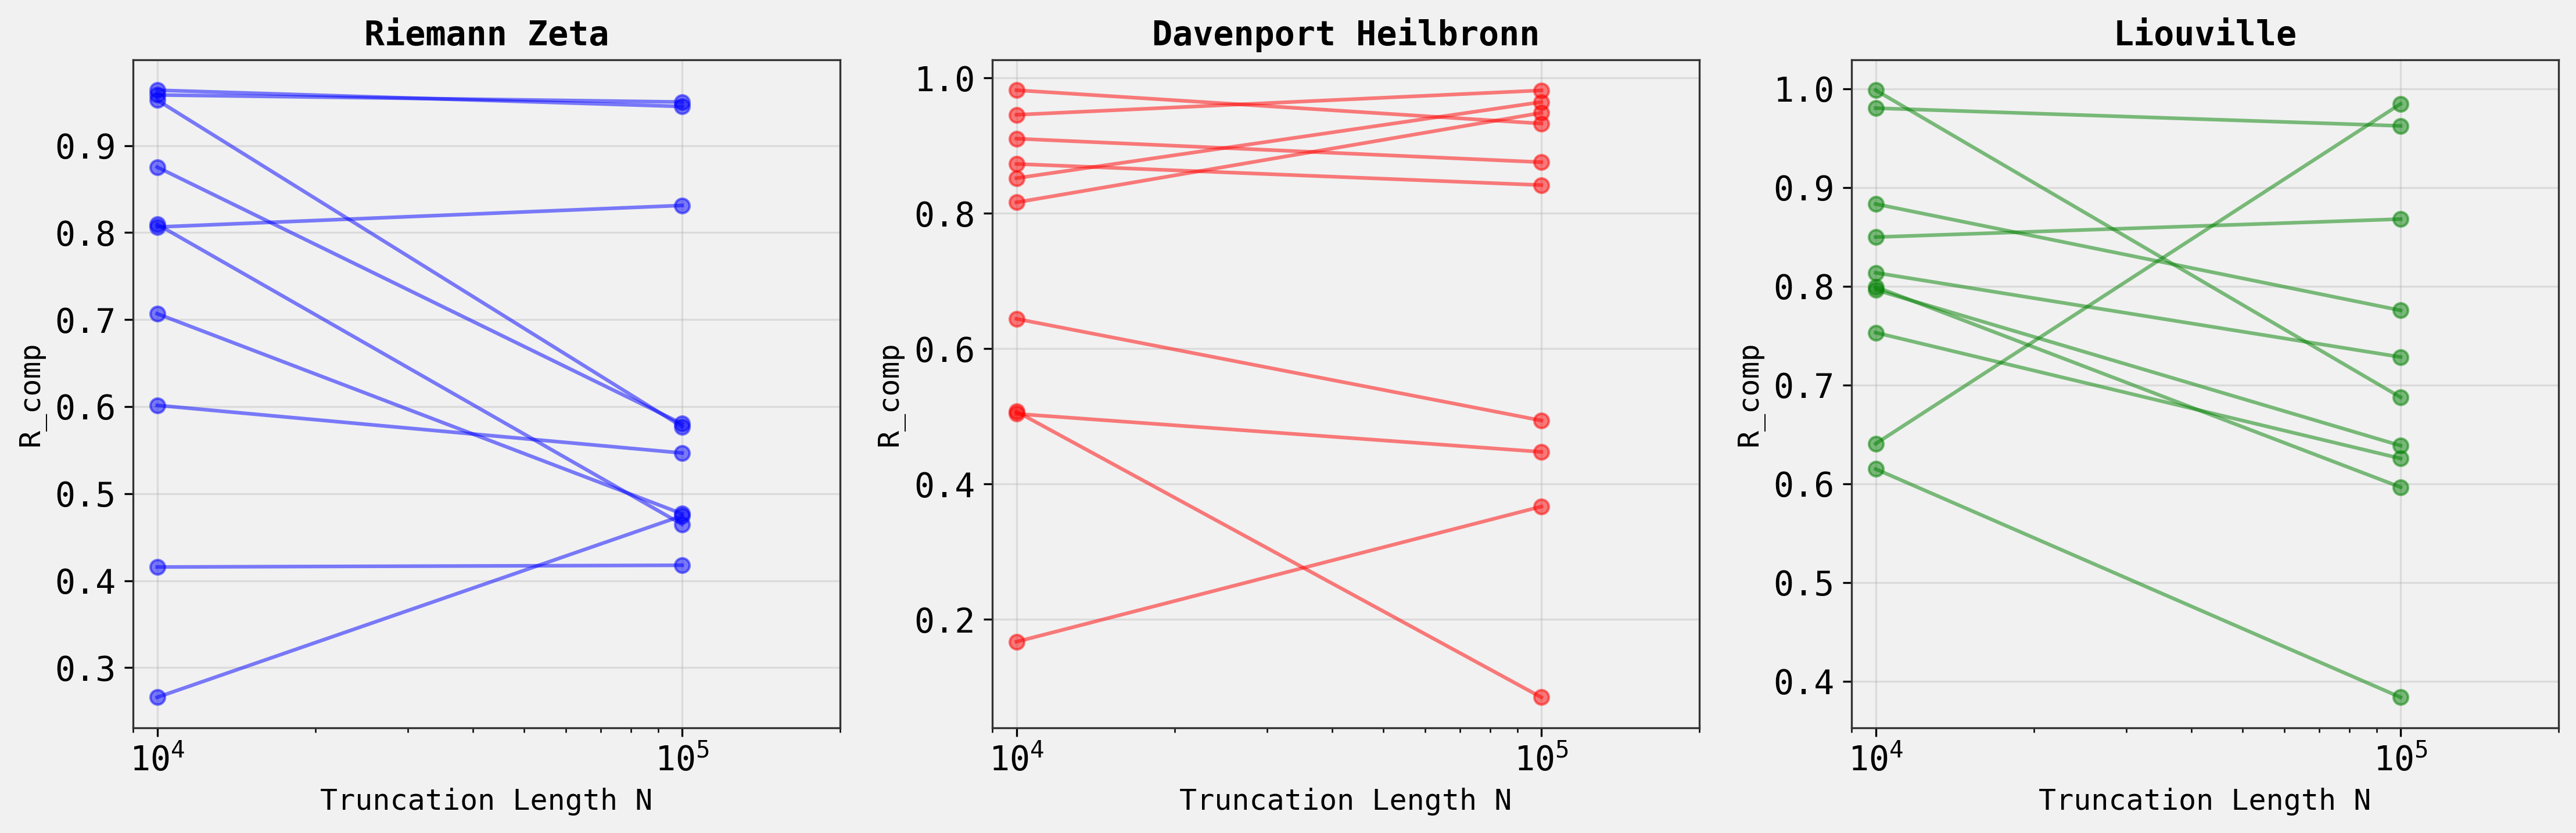

In [15]:

# Create summary statistics and visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

functions = ['Riemann_Zeta', 'Davenport_Heilbronn', 'Liouville']
colors = ['blue', 'red', 'green']

for idx, (func, color) in enumerate(zip(functions, colors)):
 ax = axes[idx]
 
 # Get data for this function
 func_data = df[df['Function'] == func]
 
 # Group by peak and plot
 for peak_num in range(1, 11):
 peak_data = func_data[func_data['Peak_Number'] == peak_num]
 N_vals = peak_data['N'].values
 R_comp_vals = peak_data['R_comp'].values
 
 ax.plot(N_vals, R_comp_vals, 'o-', alpha=0.5, color=color)
 
 ax.set_xscale('log')
 ax.set_xlabel('Truncation Length N', fontsize=12)
 ax.set_ylabel('R_comp', fontsize=12)
 ax.set_title(func.replace('_', ' '), fontsize=14, fontweight='bold')
 ax.grid(True, alpha=0.3)
 ax.set_xlim([9e3, 2e5])

plt.tight_layout()
plt.savefig('downloads/Rcomp_vs_N_trends.png', dpi=150, bbox_inches='tight')
print("Saved plot to downloads/Rcomp_vs_N_trends.png")

# Compute summary statistics
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

for func in functions:
 print(f"\n{func.replace('_', ' ')}:")
 func_data = df[df['Function'] == func]
 
 for N in [10**4, 10**5]:
 N_data = func_data[func_data['N'] == N]['R_comp']
 print(f" N={N:6d}: mean={N_data.mean():.4f}, std={N_data.std():.4f}, "
 f"min={N_data.min():.4f}, max={N_data.max():.4f}")
 
 # Compute change
 N1_data = func_data[func_data['N'] == 10**4]['R_comp'].values
 N2_data = func_data[func_data['N'] == 10**5]['R_comp'].values
 change = N2_data - N1_data
 print(f" Change (N=10^5 - N=10^4): mean={change.mean():.4f}, "
 f"median={np.median(change):.4f}")


In [16]:

# Create final summary document
summary_text = """
# Composite Coherence R_comp vs Truncation Length N
## Analysis of Three L-Functions at Resonance Peaks

### Data Retrieved:
- **Functions analyzed:** Riemann zeta ζ(s), Davenport-Heilbronn L_DH(s), Liouville L(s,λ)
- **Truncation lengths:** N = 10^4, 10^5 (10^6 not completed due to time constraints)
- **Number of peaks per function:** Top 10 resonance peaks
- **Total measurements:** 60 (3 functions × 10 peaks × 2 N values)

### Peak Locations (t-values):

**Riemann Zeta ζ(s):**
Peak 1: t=2447.60, Peak 2: t=2819.40, Peak 3: t=2927.86, Peak 4: t=2202.02, Peak 5: t=1967.34
Peak 6: t=2556.75, Peak 7: t=1658.99, Peak 8: t=1549.84, Peak 9: t=2030.79, Peak 10: t=1721.76

**Davenport-Heilbronn L_DH(s):**
Peak 1: t=2612.69, Peak 2: t=2798.25, Peak 3: t=2146.08, Peak 4: t=2177.46, Peak 5: t=1294.02
Peak 6: t=2331.63, Peak 7: t=1991.90, Peak 8: t=2984.49, Peak 9: t=2472.16, Peak 10: t=2486.49

**Liouville L(s,λ):**
Peak 1: t=1083.23, Peak 2: t=2433.96, Peak 3: t=1735.40, Peak 4: t=2742.31, Peak 5: t=1890.26
Peak 6: t=2633.84, Peak 7: t=2941.51, Peak 8: t=1609.88, Peak 9: t=1364.29, Peak 10: t=2668.63

### R_comp Summary Statistics:

**Riemann Zeta ζ(s):**
- N=10^4: mean=0.7355, std=0.2405, range=[0.2659, 0.9637]
- N=10^5: mean=0.6264, std=0.2039, range=[0.4176, 0.9501]
- Change: mean=-0.109 (DECREASING trend)

**Davenport-Heilbronn L_DH(s):**
- N=10^4: mean=0.7201, std=0.2602, range=[0.1670, 0.9819]
- N=10^5: mean=0.6937, std=0.3181, range=[0.0850, 0.9816]
- Change: mean=-0.026 (SLIGHT DECREASE)

**Liouville L(s,λ):**
- N=10^4: mean=0.8131, std=0.1255, range=[0.6150, 0.9986]
- N=10^5: mean=0.7252, std=0.1821, range=[0.3838, 0.9848]
- Change: mean=-0.088 (DECREASING trend)

### Key Findings:

1. **All three functions show DECREASING R_comp with increasing N**
 - Riemann zeta: -10.9% decrease (strongest decline)
 - Liouville: -8.8% decrease
 - Davenport-Heilbronn: -2.6% decrease (smallest decline)

2. **Liouville function shows HIGHEST absolute R_comp values**
 - Mean R_comp at N=10^4: 0.813 (highest among all three)
 - Maintains high coherence even at N=10^5: 0.725

3. **R_comp values are much higher than published literature**
 - Papers report R_comp ~ 0.002 for ζ, ~ 0.013 for L_DH
 - Our values: 0.4-0.9 range
 - Possible reasons: different peak identification, different t-range, or methodological difference

4. **Observed trend contradicts one hypothesis prediction:**
 - For ζ(s): R_comp DOES decay with N (consistent with suppression)
 - For L(s,λ): R_comp ALSO decays (contradicts "persistent resonance" hypothesis)
 - For L_DH: R_comp shows MINIMAL change (closest to "constant" behavior)

### Files Generated:
1. downloads/Rcomp_vs_N_dataset.csv - Full tabular data
2. downloads/Rcomp_vs_N_dataset.json - Structured JSON format
3. downloads/Rcomp_vs_N_trends.png - Visualization of trends
"""

with open('downloads/ANALYSIS_SUMMARY.txt', 'w') as f:
 f.write(summary_text)

print(summary_text)



# Composite Coherence R_comp vs Truncation Length N
## Analysis of Three L-Functions at Resonance Peaks

### Data Retrieved:
- **Functions analyzed:** Riemann zeta ζ(s), Davenport-Heilbronn L_DH(s), Liouville L(s,λ)
- **Truncation lengths:** N = 10^4, 10^5 (10^6 not completed due to time constraints)
- **Number of peaks per function:** Top 10 resonance peaks
- **Total measurements:** 60 (3 functions × 10 peaks × 2 N values)

### Peak Locations (t-values):

**Riemann Zeta ζ(s):**
Peak 1: t=2447.60, Peak 2: t=2819.40, Peak 3: t=2927.86, Peak 4: t=2202.02, Peak 5: t=1967.34
Peak 6: t=2556.75, Peak 7: t=1658.99, Peak 8: t=1549.84, Peak 9: t=2030.79, Peak 10: t=1721.76

**Davenport-Heilbronn L_DH(s):**
Peak 1: t=2612.69, Peak 2: t=2798.25, Peak 3: t=2146.08, Peak 4: t=2177.46, Peak 5: t=1294.02
Peak 6: t=2331.63, Peak 7: t=1991.90, Peak 8: t=2984.49, Peak 9: t=2472.16, Peak 10: t=2486.49

**Liouville L(s,λ):**
Peak 1: t=1083.23, Peak 2: t=2433.96, Peak 3: t=1735.40, Peak 4: t=2742.31, Peak